## Práctica IMDB reviews

Equipo:

<ul>
    <li>Flor Melissa Vázquez Mateo</li>
    <li>Diego Alberto Chávez Prado</li>
    <li>Cesar Ricardo Altamirano Nava</li>
    <li>Erika Margarita Villalobos Martínez</li>
</ul>

#### Se importan bibliotecas necesarias

In [1]:
#General
import numpy as np
import pandas as pd
from scipy.stats import uniform
import os
from skimpy import skim
from tqdm import tqdm

#Manejo de texto plano
import re
import emoji
import unicodedata

#Graficas
import matplotlib.pyplot as plt
import seaborn as sns

#Nube de palabras
from wordcloud import WordCloud, STOPWORDS

#Analisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

#Modelo de regresion logistica y Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

#Busqueda de hiper-parametros, train test, metricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer

#Modelo de clasificación
from sklearn.svm import SVC

In [2]:
import numpy
print("NumPy version:", numpy.__version__)
print("NumPy dtype size:", numpy.dtype('float64').itemsize)

NumPy version: 1.26.4
NumPy dtype size: 8


#### Opciones globales

In [3]:
np.random.seed(1989)

In [4]:
pd.options.display.float_format = '{:,.3f}'.format

In [5]:
#Modelo Spacy en ingles
nlp = spacy.load("en_core_web_lg", disable=["parser", "ner", "textcat"])

In [6]:
#Cargamos las stopwords
stop_words = nlp.Defaults.stop_words

In [7]:
for word in nlp.Defaults.stop_words:
    nlp.vocab[word].is_stop = True

In [8]:
#stop_words

#### Procesamiento de datos

In [9]:
# Ruta base donde están las carpetas train y test
base_path = "../data/aclImdb"

In [10]:
def read_files(split_name):
    # Lista para almacenar los datos extraídos
    data = []

    # Evitar leer archivos duplicados
    archivos_vistos = set()

    for sentiment in ["pos", "neg"]:
        folder_path = os.path.join(base_path, split_name, sentiment)
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(".txt") and filename not in archivos_vistos:
                archivos_vistos.add(filename)
                try:
                    review_id, rating = filename.replace(".txt", "").split("_")
                    review_id = int(review_id)
                    rating = int(rating)

                    file_path = os.path.join(folder_path, filename)
                    with open(file_path, "r", encoding="utf-8") as f:
                        review_text = f.read().strip()

                    data.append({
                        "review_id": review_id,
                        "review": review_text,
                        "rating": rating,
                        "sentiment": sentiment
                    })
                except Exception as e:
                    print(f"Error procesando {filename}: {e}")
    return pd.DataFrame(data)

In [11]:
df_train = read_files("train")
df_test = read_files("test")

In [12]:
df_train.head()

,review_id,review,rating,sentiment
0,0,Bromwell High is a cartoon comedy. It ran at t...,9,pos
1,10000,Homelessness (or Houselessness as George Carli...,8,pos
2,10001,Brilliant over-acting by Lesley Ann Warren. Be...,10,pos
3,10002,This is easily the most underrated film inn th...,7,pos
4,10003,This is not the typical Mel Brooks film. It wa...,8,pos


In [13]:
print("Archivos únicos:", df_train["review_id"].nunique())
print("Total de archivos:", len(df_train))
print("Duplicados:", df_train.duplicated().sum())

Archivos únicos: 12500
Total de archivos: 25000
Duplicados: 0


In [14]:
import glob

train_pos = glob.glob(os.path.join(base_path, "train", "pos", "*.txt"))
train_neg = glob.glob(os.path.join(base_path, "train", "neg", "*.txt"))
print("Positivos:", len(train_pos))
print("Negativos:", len(train_neg))
print("Total esperados:", len(train_pos) + len(train_neg))

Positivos: 12500
Negativos: 12500
Total esperados: 25000


In [15]:
df_train["sentiment"].value_counts(normalize = True)

sentiment
pos   0.500
neg   0.500
Name: proportion, dtype: float64

In [16]:
df_test.head()

,review_id,review,rating,sentiment
0,0,I went and saw this movie last night after bei...,10,pos
1,10000,Actor turned director Bill Paxton follows up h...,7,pos
2,10001,As a recreational golfer with some knowledge o...,9,pos
3,10002,"I saw this film in a sneak preview, and it is ...",8,pos
4,10003,Bill Paxton has taken the true story of the 19...,8,pos


In [17]:
print("Archivos únicos:", df_test["review_id"].nunique())
print("Total de archivos:", len(df_test))
print("Duplicados:", df_test.duplicated().sum())

Archivos únicos: 12500
Total de archivos: 25000
Duplicados: 0


In [18]:
test_pos = glob.glob(os.path.join(base_path, "test", "pos", "*.txt"))
test_neg = glob.glob(os.path.join(base_path, "test", "neg", "*.txt"))
print("Positivos:", len(test_pos))
print("Negativos:", len(test_neg))
print("Total esperados:", len(test_pos) + len(test_neg))

Positivos: 12500
Negativos: 12500
Total esperados: 25000


In [19]:
df_test["sentiment"].value_counts(normalize = True)

sentiment
pos   0.500
neg   0.500
Name: proportion, dtype: float64

In [20]:
#Aplicamos la transformacion a 0 y 1 del sentiment; 0=negativo, 1=positivo
df_train['sentiment'] = df_train['sentiment'].apply(lambda x: 0 if 'neg' in x else 1)
df_test['sentiment'] = df_test['sentiment'].apply(lambda x: 0 if 'neg' in x else 1)

In [21]:
print(f"Tamaño de los datos: {df_train.shape}")

Tamaño de los datos: (25000, 4)


In [22]:
print(f"Tamaño de los datos: {df_test.shape}")

Tamaño de los datos: (25000, 4)


**Tenemos 4 variables:**

<ul>
    <li>review_id:
        Id de la reseña</li>
    <li>review: Reseña dada</li>
    <li>rating: Calificación dada a la película</li>
    <li>sentiment: Si la reseña es positiva o negativa</li>
</ul>

Quitaremos la variable review_id, me percaté que el valor se repite debido a que llevan una numeración similar las reseñas positivas y negativas.
<br>También quitaremos la variable rating, debido a que lo que nos interesa clasificar es la reseña, la calificación no será relevante.</br>
La variable sentiment será reemplazada por 0 y 1 donde; 0=reseña negativa y 1=reseña positiva.

In [23]:
df_train.head()

,review_id,review,rating,sentiment
0,0,Bromwell High is a cartoon comedy. It ran at t...,9,1
1,10000,Homelessness (or Houselessness as George Carli...,8,1
2,10001,Brilliant over-acting by Lesley Ann Warren. Be...,10,1
3,10002,This is easily the most underrated film inn th...,7,1
4,10003,This is not the typical Mel Brooks film. It wa...,8,1


In [24]:
df_train = df_train.drop(["review_id", "rating"], axis = 1)
df_test = df_test.drop(["review_id", "rating"], axis = 1)

In [25]:
df_train.head()

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [26]:
df_test.head()

,review,sentiment
0,I went and saw this movie last night after bei...,1
1,Actor turned director Bill Paxton follows up h...,1
2,As a recreational golfer with some knowledge o...,1
3,"I saw this film in a sneak preview, and it is ...",1
4,Bill Paxton has taken the true story of the 19...,1


#### Limpieza de texto

In [27]:
def limpiar_dataframe(df, columna="review"):
    textos = df[columna].tolist()
    resultados = []

    # Preprocesamiento básico antes de spaCy
    textos_preprocesados = [
        re.sub(r"<.*?>", " ", re.sub(r"http\S+|www\.\S+", " ", t)).lower()
        for t in textos
    ]

    # Procesamiento en lote con spaCy
    for doc in tqdm(nlp.pipe(textos_preprocesados, batch_size=1000, n_process=4)):
        tokens = [
            token.lemma_
            for token in doc
            if not token.is_stop and not token.is_punct and token.is_alpha and len(token) > 2
        ]
        resultados.append(tokens if tokens else None)

    return resultados

In [28]:
df_train["tokens"] = limpiar_dataframe(df_train)
df_test["tokens"] = limpiar_dataframe(df_test)

25000it [07:23, 56.34it/s] 
25000it [06:32, 63.63it/s] 


In [29]:
df_train.sample(20)

,review,sentiment,tokens
22141,"As usual, on IMDb, going by the majority vote ...",0,"[usual, imdb, go, majority, vote, instead, wei..."
1633,Everyone knows about this ''Zero Day'' event. ...,1,"[know, zero, day, event, think, movie, elephan..."
20557,This may sound crazy to even the people who re...,0,"[sound, crazy, people, remember, remember, liv..."
4491,It's such a shame that because of it's title t...,1,"[shame, title, film, avoid, people, hate, foot..."
24943,Had the original casting idea been kept (hunti...,0,"[original, casting, idea, keep, hunting, rutge..."
3306,"While thinking of ""The Great Escape"" I allowed...",1,"[think, great, escape, allow, mind, wander, li..."
23680,Ok I will sum up this movie... A bunch of skan...,0,"[sum, movie, bunch, skanky, british, woman, di..."
20027,"The problem with family dramas is that, outsid...",0,"[problem, family, drama, outside, movie, chann..."
12860,Little Mosque is one of the most boring CBC co...,0,"[little, mosque, boring, cbc, comedy, see, way..."
6935,"Unfortunately, this film has long been unavail...",1,"[unfortunately, film, long, unavailable, poste..."


In [30]:
df_test.sample(20)

,review,sentiment,tokens
22743,I have neither read the book on which the movi...,0,"[read, book, movie, base, letter, vita, violet..."
328,Forget the recent dire American remake which s...,1,"[forget, recent, dire, american, remake, sadly..."
15019,this movie is one that belongs on the cutting ...,0,"[movie, belong, cutting, room, floor, opening,..."
20649,this is the worst film I've seen in a long lon...,0,"[bad, film, see, long, long, time, mind, fact,..."
5197,"An interesting comedy, taking place on a train...",1,"[interesting, comedy, take, place, train, stoc..."
10344,This is a film that every child should see bef...,1,"[film, child, grow, distort, pass, idea, gener..."
72,If this film had been made in the 50's or 60's...,1,"[film, critic, fan, alike, praise, enjoy, film..."
13636,"I'm starting to wonder, after reading some of ...",0,"[start, wonder, read, opinion, watch, film, re..."
3234,There are not many films which I would describ...,1,"[film, describe, perfect, rififi, definitely, ..."
14668,This movie had all the potential and makings o...,0,"[movie, potential, making, great, feel, good, ..."


In [31]:
# Eliminar filas sin tokens (mensajes vacíos o solo links)
df_train = df_train.dropna(subset=["tokens"]).reset_index(drop=True)
df_test = df_test.dropna(subset=["tokens"]).reset_index(drop=True)

In [32]:
df_train.sample(20)

,review,sentiment,tokens
16126,This film is roughly what it sounds like: a fu...,0,"[film, roughly, sound, like, futuristic, versi..."
11282,"Old horror movies are interesting, plenty of s...",1,"[old, horror, movie, interesting, plenty, scre..."
14362,This was talked about to death by the critics ...,0,"[talk, death, critic, honestly, great, sure, c..."
15389,This film essentially deals with Inspector Gad...,0,"[film, essentially, deal, inspector, gadget, a..."
10619,It is fitting on a musical Sunday to get your ...,1,"[fitting, musical, sunday, heart, pumping, wel..."
19193,What a complete waste of time. The movie start...,0,"[complete, waste, time, movie, start, clone, s..."
20477,"Hey,<br /><br />If your going to make a docume...",0,"[hey, go, documentary, leonard, cohen, try, ma..."
15766,this movie was horrible. I could barely stay a...,0,"[movie, horrible, barely, stay, awake, movie, ..."
8485,"Here's what I knew about ""Atlantis"" before wat...",1,"[know, atlantis, watch, officially, disney, an..."
22042,Maya is a woman without any interests. She jus...,0,"[maya, woman, interest, dream, life, away, won..."


In [33]:
df_test.sample(20)

,review,sentiment,tokens
22307,"I don't know, but the movie was just too simil...",0,"[know, movie, similar, movie, see, ring, eye, ..."
5055,LACKAWANNA BLUES is a fine stage play by Ruben...,1,"[lackawanna, blue, fine, stage, play, ruben, s..."
10306,This is the classic case of an excellent film ...,1,"[classic, case, excellent, film, look, america..."
11135,"I am a massive Hitchcock fan, ever since seein...",1,"[massive, hitchcock, fan, see, rear, window, t..."
18492,"I wanted to dog this movie, but somehow I can'...",0,"[want, dog, movie, find, exhibit, duality, fig..."
3980,"Starring: Kelsey Grammar, Rob Schneider, Laure...",1,"[star, kelsey, grammar, rob, schneider, lauren..."
22736,I don't dislike Cary Grant but I've found his ...,0,"[dislike, cary, grant, find, performance, anno..."
23467,"More suspenseful, more subtle, much, much more...",0,"[suspenseful, subtle, disturbing]"
20112,I don't honestly know what legal or illegal su...,0,"[honestly, know, legal, illegal, substance, wr..."
11568,"From the first to the last scene, this film is...",1,"[scene, film, realistically, realistically, de..."


In [34]:
#Quitamos listas de tokens vacias
df_train = df_train[df_train["tokens"].apply(lambda x: len(x) > 0)].reset_index(drop=True)
df_test = df_test[df_test["tokens"].apply(lambda x: len(x) > 0)].reset_index(drop=True)

In [35]:
df_train.sample(20)

,review,sentiment,tokens
10937,I can admit that the screenplay isn't very goo...,1,"[admit, screenplay, good, slow, part, critic, ..."
15369,The novelty of hearing clean-cut Jay Leno spou...,0,"[novelty, hear, clean, cut, jay, leno, spout, ..."
3048,"A classy offering from Amicus, producer Milton...",1,"[classy, offering, amicus, producer, milton, s..."
9035,On rare occasions a film comes along that has ...,1,"[rare, occasion, film, come, power, expand, mi..."
6567,I can only echo the praise of the other review...,1,"[echo, praise, review, delightful, film, feelg..."
3513,"I'll keep it short and brief, the people who w...",1,"[short, brief, people, write, story, line, gen..."
24997,I saw 'Descent' last night at the Stockholm Fi...,0,"[see, descent, night, stockholm, film, festiva..."
16472,the first Scanners may not have been a great m...,0,"[scanner, great, movie, novelty, acting, bad, ..."
2003,"""Sasquatch Hunters"" actually wasn't as bad as ...",1,"[sasquatch, hunter, actually, bad, think, spoi..."
9115,My Super X-Girlfriend is one hell of a roller ...,1,"[super, girlfriend, hell, roller, coaster, rid..."


In [36]:
df_test.sample(20)

,review,sentiment,tokens
16552,The 3 stars are for Phillip Seymour Hoffman. N...,0,"[star, phillip, seymour, hoffman, movie, deser..."
5504,Mom has to be one of the all time uncomfortabl...,1,"[mom, time, uncomfortable, movie, watch, featu..."
23593,First and foremost I'd like to state - for the...,0,"[foremost, like, state, record, incredibly, du..."
16541,Four Guys (Jacks) go into the restaurant busin...,0,"[guy, jack, restaurant, business, fifth, guy, ..."
16653,There is no real story the film seems more lik...,0,"[real, story, film, like, fly, wall, drama, do..."
8888,I think this movie was made as good as it coul...,1,"[think, movie, good, month, budget, surprised,..."
13673,Bottom-of-the-barrel stinker is so bad it's be...,0,"[barrel, stinker, bad, funny, plot, american, ..."
1235,"Great cast, great acting, great music. Each ch...",1,"[great, cast, great, acting, great, music, cha..."
15626,Cultural Vandalism Is the new Hallmark product...,0,"[cultural, vandalism, new, hallmark, productio..."
17559,"Above all, you must not take this movie seriou...",0,"[movie, seriously, take, seriously, unfortunat..."


In [37]:
#Definimos una lista de todas las palabras dataset train
all_words_train = [word for tokens in df_train["tokens"] for word in tokens]
freq_train = Counter(all_words_train)

In [38]:
#Definimos una lista de todas las palabras dataset test
all_words_test = [word for tokens in df_test["tokens"] for word in tokens]
freq_test = Counter(all_words_test)

In [39]:
#Definimos los hapaxes (palabras que solo aparecen 1 vez) dataset train
hapaxes = {word for word, count in freq_train.items() if count == 1}

In [40]:
#Definimos los hapaxes (palabras que solo aparecen 1 vez) dataset test
hapaxes = {word for word, count in freq_test.items() if count == 1}

In [41]:
#Función para eliminar hapaxes
def remove_hapaxes(tokens):
    return [t for t in tokens if t not in hapaxes]

In [42]:
#Aplicamos 
df_train["tokens"] = df_train["tokens"].apply(remove_hapaxes)
df_test["tokens"] = df_test["tokens"].apply(remove_hapaxes)

In [43]:
# Crear columna de texto limpio (para WordCloud y TF-IDF)
df_train["Texto_limpio"] = df_train["tokens"].apply(lambda x: " ".join(x))
df_test["Texto_limpio"] = df_test["tokens"].apply(lambda x: " ".join(x))

In [44]:
#Quitamos acentos
def normalize_text(text):
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    return text

In [45]:
df_train["Texto_limpio"] = df_train["Texto_limpio"].map(normalize_text)
df_test["Texto_limpio"] = df_test["Texto_limpio"].map(normalize_text)

In [46]:
df_train.head()

,review,sentiment,tokens,Texto_limpio
0,Bromwell High is a cartoon comedy. It ran at t...,1,"[bromwell, high, cartoon, comedy, run, time, p...",bromwell high cartoon comedy run time program ...
1,Homelessness (or Houselessness as George Carli...,1,"[homelessness, houselessness, george, carlin, ...",homelessness houselessness george carlin state...
2,Brilliant over-acting by Lesley Ann Warren. Be...,1,"[brilliant, act, lesley, ann, warren, good, dr...",brilliant act lesley ann warren good dramatic ...
3,This is easily the most underrated film inn th...,1,"[easily, underrated, film, inn, brooks, cannon...",easily underrated film inn brooks cannon sure ...
4,This is not the typical Mel Brooks film. It wa...,1,"[typical, mel, brooks, film, slapstick, movie,...",typical mel brooks film slapstick movie actual...


In [47]:
df_test.head()

,review,sentiment,tokens,Texto_limpio
0,I went and saw this movie last night after bei...,1,"[go, see, movie, night, coax, friend, admit, r...",go see movie night coax friend admit reluctant...
1,Actor turned director Bill Paxton follows up h...,1,"[actor, turn, director, bill, paxton, follow, ...",actor turn director bill paxton follow promisi...
2,As a recreational golfer with some knowledge o...,1,"[recreational, golfer, knowledge, sport, histo...",recreational golfer knowledge sport history pl...
3,"I saw this film in a sneak preview, and it is ...",1,"[see, film, sneak, preview, delightful, cinema...",see film sneak preview delightful cinematograp...
4,Bill Paxton has taken the true story of the 19...,1,"[bill, paxton, take, true, story, golf, open, ...",bill paxton take true story golf open film ext...


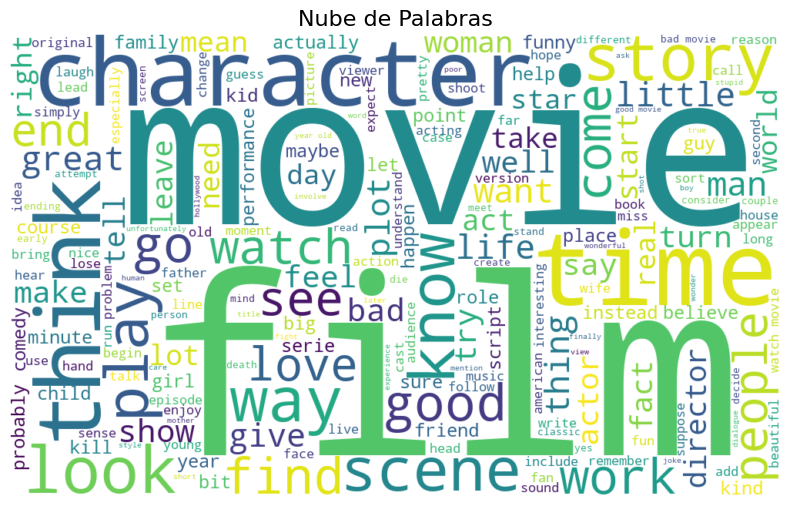

In [48]:
texto_total = " ".join(df_train["Texto_limpio"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras", fontsize=16)
plt.show()

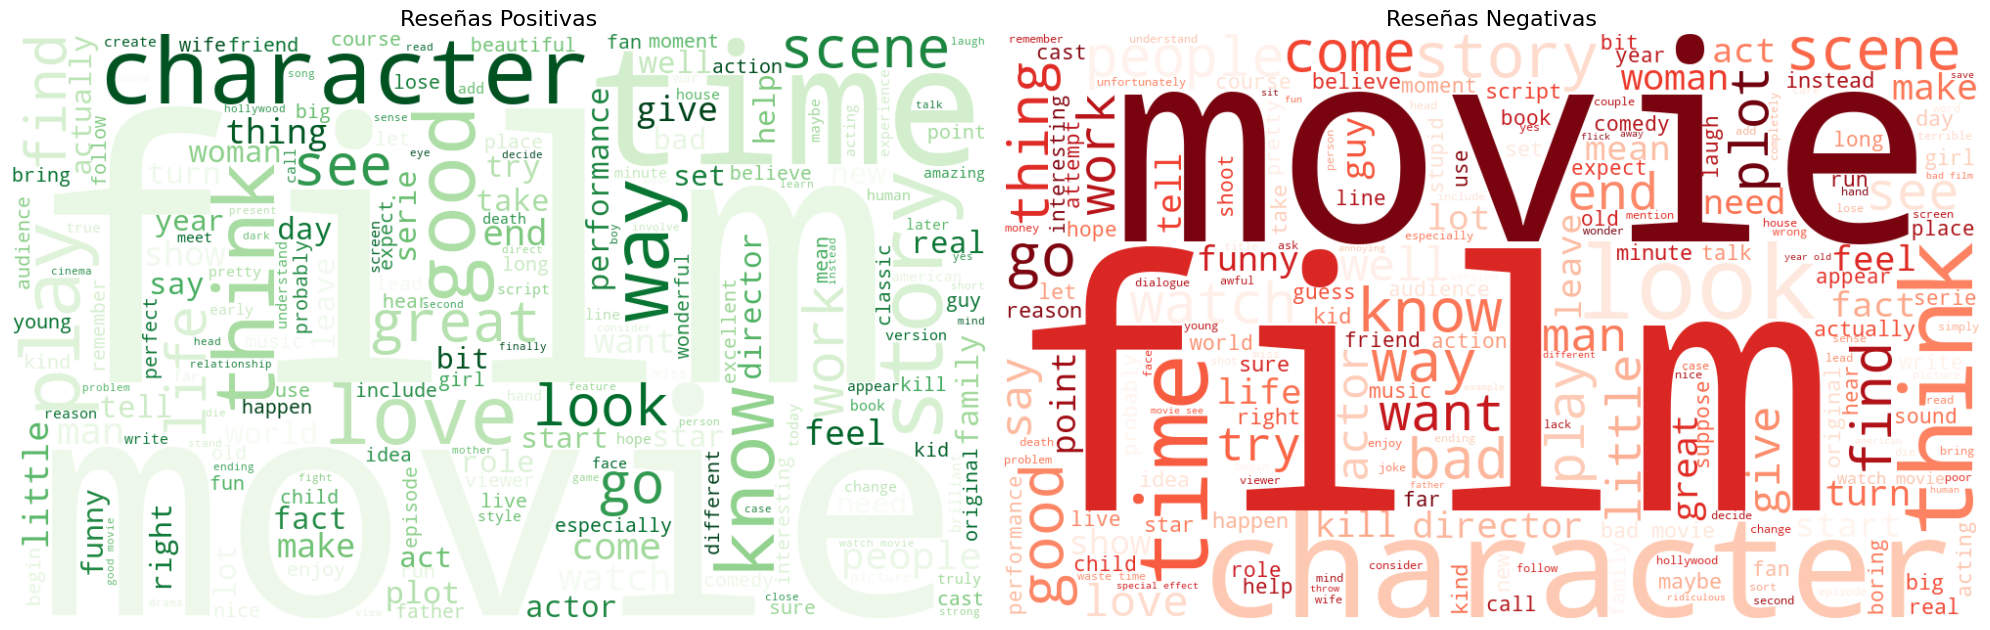

In [49]:
# Word cloud para reseñas positivas
texto_pos = " ".join(df_train[df_train["sentiment"] == 1]["Texto_limpio"].tolist())
wordcloud_pos = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="Greens"
).generate(texto_pos)

# Word cloud para reseñas negativas
texto_neg = " ".join(df_train[df_train["sentiment"] == 0]["Texto_limpio"].tolist())
wordcloud_neg = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="Reds"
).generate(texto_neg)

# Mostrar ambas nubes
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].imshow(wordcloud_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Reseñas Positivas", fontsize=16)

axes[1].imshow(wordcloud_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Reseñas Negativas", fontsize=16)

plt.tight_layout()
plt.show()

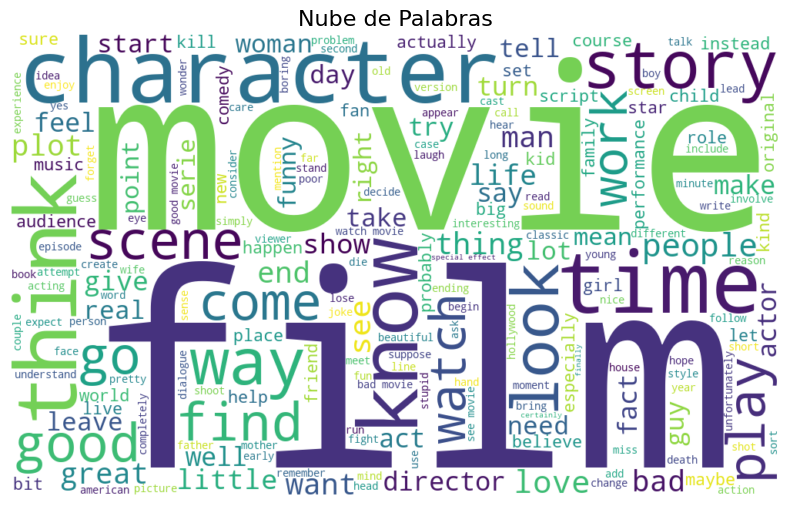

In [50]:
texto_total = " ".join(df_test["Texto_limpio"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras", fontsize=16)
plt.show()

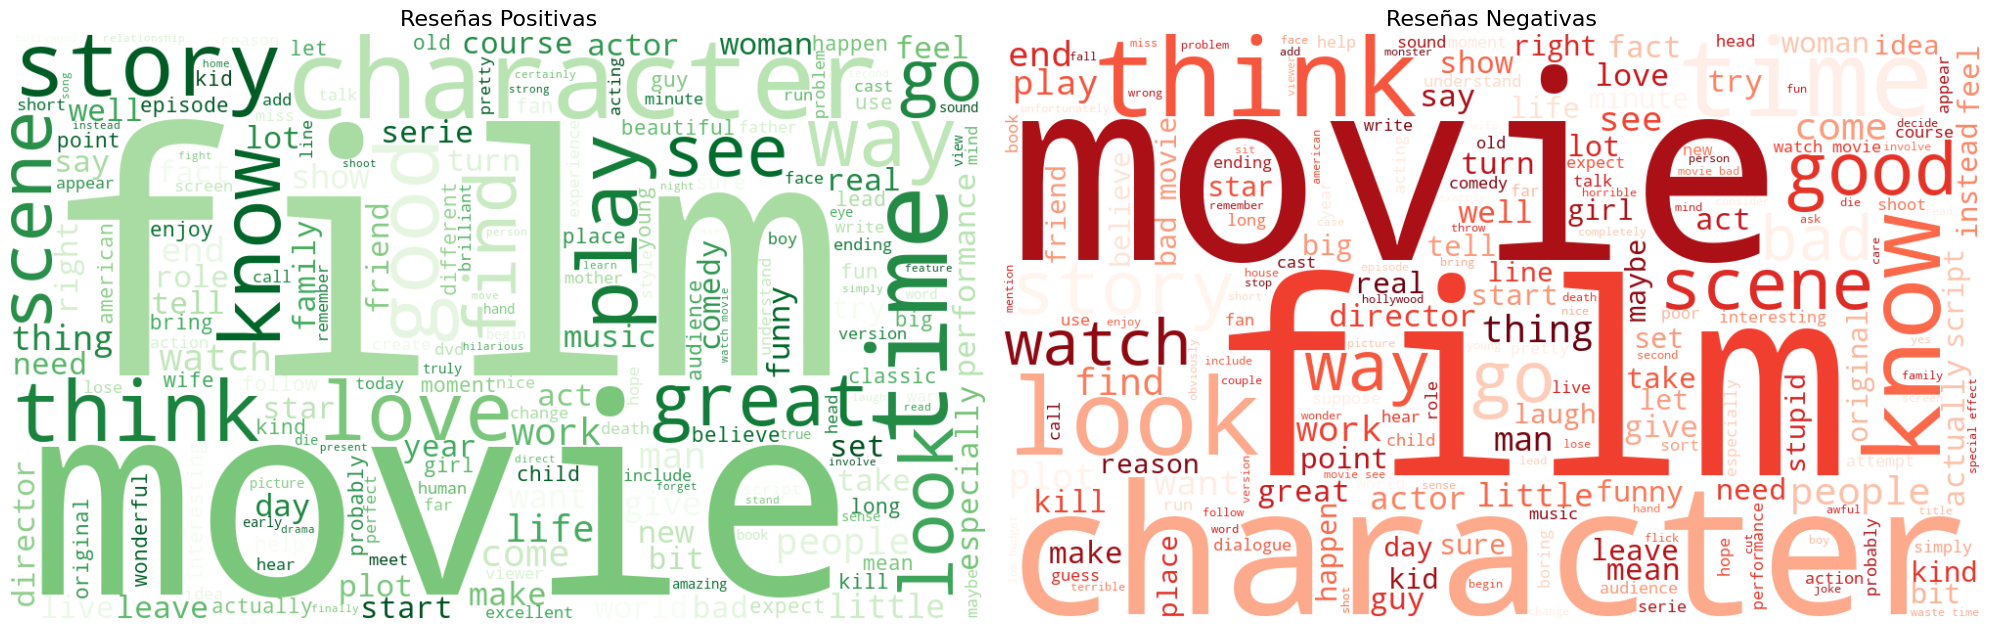

In [51]:
# Word cloud para reseñas positivas
texto_pos = " ".join(df_test[df_test["sentiment"] == 1]["Texto_limpio"].tolist())
wordcloud_pos = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="Greens"
).generate(texto_pos)

# Word cloud para reseñas negativas
texto_neg = " ".join(df_test[df_test["sentiment"] == 0]["Texto_limpio"].tolist())
wordcloud_neg = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="Reds"
).generate(texto_neg)

# Mostrar ambas nubes
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].imshow(wordcloud_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Reseñas Positivas", fontsize=16)

axes[1].imshow(wordcloud_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Reseñas Negativas", fontsize=16)

plt.tight_layout()
plt.show()

### Modelado

In [52]:
X_train = df_train["Texto_limpio"]
X_test = df_test["Texto_limpio"]

y_train = df_train["sentiment"]
y_test = df_test["sentiment"]

In [53]:
#Vectorizamos
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), 
    min_df= 0.001,
    max_df=0.7,
    stop_words=None
)

In [54]:
# Ajustamos con el train y transformamos ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [55]:
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

Train shape: (25000, 5000)
Test shape:  (25000, 5000)


#### Bayes Classifier

In [56]:
#Función para evaluación del rendimiento
def evaluate_model(model, X, y, dataset_name="Dataset"):
    y_pred_default = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    #Métricas con umbral 0.5
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    cm = confusion_matrix(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, y_proba)

    print(f"\n=== Resultados en {dataset_name} (umbral = 0.5) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")

    #Calibración con J de Youden
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:          {best_threshold:.4f}")
    print(f"Sensibilidad óptima:    {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima:   {specificity[idx_opt]:.4f}")

    #Recalcular métricas con umbral óptimo
    y_pred_opt = (y_proba >= best_threshold).astype(int)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    cm_opt = confusion_matrix(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")

    #Curva ROC con umbral óptimo
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})", color='blue')
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend()
    plt.show()

In [57]:
#Creamos un grid para el mejor alpha
param_grid = {"alpha": np.logspace(-3, 1, 10)}  # valores desde 0.001 hasta 10
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

,estimator,MultinomialNB()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10.0


In [58]:
best_alpha = grid.best_params_["alpha"]
print(f"Mejor alfa encontrado: {best_alpha:.4f}")

Mejor alfa encontrado: 10.0000


In [59]:
# Modelo final
nb = MultinomialNB(alpha=best_alpha)
nb.fit(X_train_tfidf, y_train)

,alpha,10.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [60]:
#Validación cruzada
cv_scores = cross_val_score(nb, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8314
Mediana: 0.8338
Desviación estándar: 0.0055



=== Resultados en Train (umbral = 0.5) ===
Accuracy:      0.8655
Sensibilidad:  0.8732
Especificidad: 0.8578
AUC:           0.9376

--- Calibración Youden J ---
Umbral óptimo:          0.4997
Sensibilidad óptima:    0.8738
Especificidad óptima:   0.8574

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.8656
Sensibilidad:  0.8738
Especificidad: 0.8574


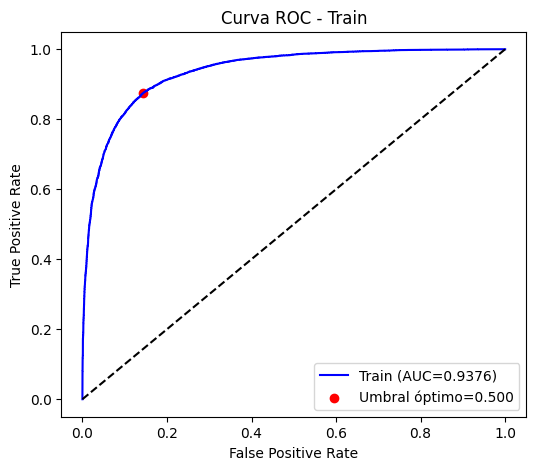


=== Resultados en Test (umbral = 0.5) ===
Accuracy:      0.8440
Sensibilidad:  0.8328
Especificidad: 0.8551
AUC:           0.9225

--- Calibración Youden J ---
Umbral óptimo:          0.4867
Sensibilidad óptima:    0.8547
Especificidad óptima:   0.8371

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8459
Sensibilidad:  0.8547
Especificidad: 0.8371


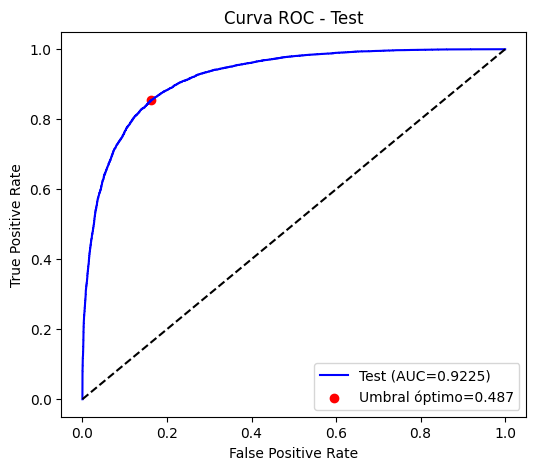

In [61]:
evaluate_model(nb, X_train_tfidf, y_train, "Train")
evaluate_model(nb, X_test_tfidf, y_test, "Test")

#### Regresión logística

In [92]:
#Instanciamos el modelo
log_reg = LogisticRegression(max_iter=500, penalty = "l2", solver = "lbfgs")

In [93]:
#Mejor parametro C
param_grid_log = {
    "C": np.logspace(-3, 3, 7),  # valores entre 0.001 y 1000
}

In [94]:
#Búsqueda aleatoria
log_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_grid_log,
    n_iter=7,
    scoring="accuracy",
    cv=5,
    random_state=1989,
    n_jobs=-1
)

In [95]:
import time

start = time.time()

In [96]:
log_search.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre...(max_iter=500)
,param_distributions,"{'C': array([1.e-03...e+02, 1.e+03])}"
,n_iter,7
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1989
,error_score,nan


In [97]:
print("Tiempo total:", time.time() - start)

Tiempo total: 6.336693286895752


In [98]:
#Mejores parámetros
best_log = log_search.best_estimator_
print("Mejores parámetros Logistic Regression:", log_search.best_params_)

Mejores parámetros Logistic Regression: {'C': 1.0}


In [99]:
best_c = log_search.best_params_["C"]

##### Mejores hiperparams Regresión logística

In [100]:
#Mejor modelo
best_reglog = log_search.best_estimator_

In [101]:
#Validación cruzada
cv_scores = cross_val_score(best_reglog, X_train_tfidf, y_train, cv=5, scoring="accuracy")

print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8522
Mediana: 0.8500
Desviación estándar: 0.0047



=== Resultados en Train (umbral = 0.5) ===
Accuracy:      0.9113
Sensibilidad:  0.9238
Especificidad: 0.8987
AUC:           0.9699

--- Calibración Youden J ---
Umbral óptimo:          0.5151
Sensibilidad óptima:    0.9190
Especificidad óptima:   0.9077

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9133
Sensibilidad:  0.9190
Especificidad: 0.9077


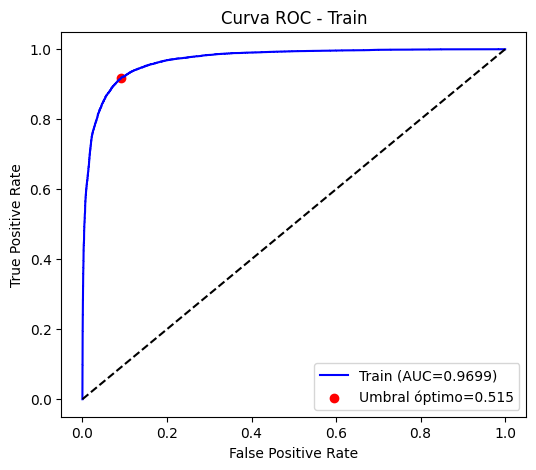


=== Resultados en Test (umbral = 0.5) ===
Accuracy:      0.8754
Sensibilidad:  0.8803
Especificidad: 0.8704
AUC:           0.9476

--- Calibración Youden J ---
Umbral óptimo:          0.4920
Sensibilidad óptima:    0.8857
Especificidad óptima:   0.8658

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8757
Sensibilidad:  0.8857
Especificidad: 0.8658


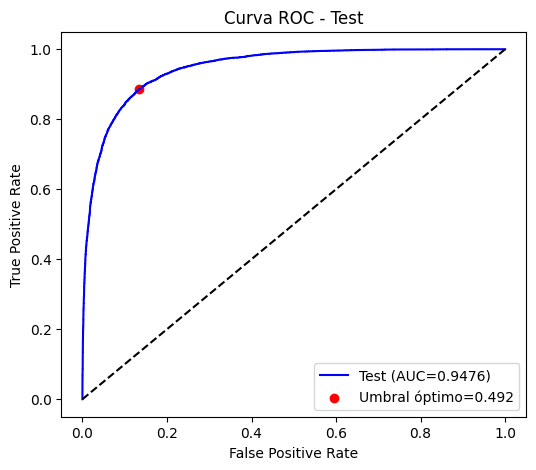

In [102]:
#Evaluación del rendimiento
evaluate_model(best_reglog, X_train_tfidf, y_train, "Train")
evaluate_model(best_reglog, X_test_tfidf, y_test, "Test")

#### SVM - Support Vector Machine

In [103]:
#Función auxiliar para métricas
def compute_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y_true, y_proba)
    return acc, sens, spec, auc

In [104]:
#Espacios de búsqueda
param_dist = {
    'linear': {'C': np.logspace(-3, 3, 20)}
}

In [ ]:
results = []

for kernel in ['linear']:
    print(f"\nEntrenando kernel: {kernel.upper()}")
    
    svc = SVC(kernel=kernel)
    random_search = RandomizedSearchCV(
        svc,
        param_distributions=param_dist[kernel],
        n_iter=5,
        scoring='roc_auc',
        cv=5,
        random_state=1989,
        n_jobs=-1
    )
    random_search.fit(X_train_tfidf, y_train)
    best_model = random_search.best_estimator_
    
    # Predicciones
    y_pred_train = best_model.predict(X_train_tfidf)
    y_proba_train = best_model.predict_proba(X_train_tfidf)[:, 1]
    y_pred_test = best_model.predict(X_test_tfidf)

    # Métricas
    acc_train, sens_train, spec_train, auc_train = compute_metrics(y_train, y_pred_train, y_proba_train)
    acc_test, sens_test, spec_test, auc_test = compute_metrics(y_test, y_pred_test, y_proba_test)
    
    results.append({
        'Kernel': kernel,
        'Best Params': random_search.best_params_,
        'Train_Accuracy': acc_train,
        'Test_Accuracy': acc_test,
        'Train_Sensitivity': sens_train,
        'Test_Sensitivity': sens_test,
        'Train_Specificity': spec_train,
        'Test_Specificity': spec_test,
        'Train_AUC': auc_train,
        'Test_AUC': auc_test
    })


Entrenando kernel: LINEAR


In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Test_AUC', ascending=False).reset_index(drop=True)
display(df_results)

In [ ]:
print("\n Búsqueda completa. Mejor kernel según AUC de prueba:")
print(df_results.iloc[0])

In [ ]:
df_results.iloc[0][1]

#### Guardamos el mejor modelo

In [62]:
nb.best_threshold_ = 0.4867

In [63]:
def predict_calibrado(model, X):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= model.best_threshold_).astype(int)

In [64]:
import pickle

modelo_calibrado = {
    "modelo": nb,
    "threshold": 0.4867,
    "vectorizer": tfidf
}

with open("best_nb.pkl", "wb") as f:
    pickle.dump(modelo_calibrado, f)

#### Abrimos el modelo

In [65]:
with open("best_nb.pkl", "rb") as f:
    modelo_cargado = pickle.load(f)

modelo = modelo_cargado["modelo"]
threshold = modelo_cargado["threshold"]
tfidf = modelo_cargado["vectorizer"]

In [66]:
modelo

,alpha,10.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [67]:
threshold

0.4867

#### Usamos el modelo

In [68]:
def limpiar_texto(texto):
    import re
    texto = re.sub(r"<.*?>", " ", re.sub(r"http\S+|www\.\S+", " ", texto)).lower()
    doc = nlp(texto)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and token.is_alpha and len(token) > 2
    ]
    return tokens

In [69]:
#Función para recibir un mensaje y predecir quien lo dijo
def predict_review(text, model, vectorizer, threshold=None):
    # Limpiar texto
    tokens = limpiar_texto(text)
    if not tokens:
        return "Mensaje vacío o sin contenido válido", 0.0
    
    # Convertir tokens a texto (TF-IDF espera texto crudo)
    text_clean = " ".join(tokens)
    
    # Vectorizar
    X_vect = vectorizer.transform([text_clean])
    
    # Obtener probabilidades
    proba = model.predict_proba(X_vect)[0, 1]  # probabilidad de clase positiva
    
    # Determinar umbral de decisión
    if threshold is None:
        threshold = getattr(model, "best_threshold_", 0.5)
    
    # Predicción calibrada
    pred = int(proba >= threshold)
    
    # Asignar tipo de reseña
    sentiment = "Escribiste una reseña negativa" if pred == 0 else "Escribiste una reseña positiva"
    
    return sentiment, proba

In [74]:
sentiment, prob = predict_review("The film Parallel Territories depicts a team investigating anomalies in a desert. It stands out for its clear cinematography, although some transitions are unevenly paced. Even so, the story maintains its structure and reaches a coherent conclusion.", modelo, tfidf, threshold)

In [75]:
print(f"Clasificación de tu reseña: {sentiment}, probabilidad: {prob}")

Clasificación de tu reseña: Escribiste una reseña positiva, probabilidad: 0.5989675314696953
